# Evaluación — Cancelaciones de reservas hoteleras

- **Proyecto:** Práctica Final · Machine Learning y Deep Learning
- **Fase:** 5 — Evaluación

## Objetivo

Evaluar visualmente los modelos entrenados en la Fase 4, con foco en el
modelo ganador (RandomForest optimizado). Generamos:

1. Gráfico de barras comparando el ROC-AUC de los 8 modelos.
2. Curvas RO

In [6]:
"""Setup del notebook de evaluacion."""

import sys
from pathlib import Path

PATH_PROYECTO = Path.cwd().parents[1] if "notebooks" in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(PATH_PROYECTO))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import evaluation
from src.metrics_io import cargar_todas_las_metricas

print(f"Raiz del proyecto: {PATH_PROYECTO}")

Raiz del proyecto: c:\Juan\Pontia\ML\practica-final-ml\practica-final-ml


## 1. Comparativa de ROC-AUC (gráfico de barras)

Cargamos las métricas persistidas en disco (de la Fase 4) y comparamos el
ROC-AUC de los 8 modelos. No requiere reentrenar: lee de `resultados/metricas/`.

Figura guardada: C:\Juan\Pontia\ML\practica-final-ml\practica-final-ml\resultados\figuras\barras_roc_auc.png


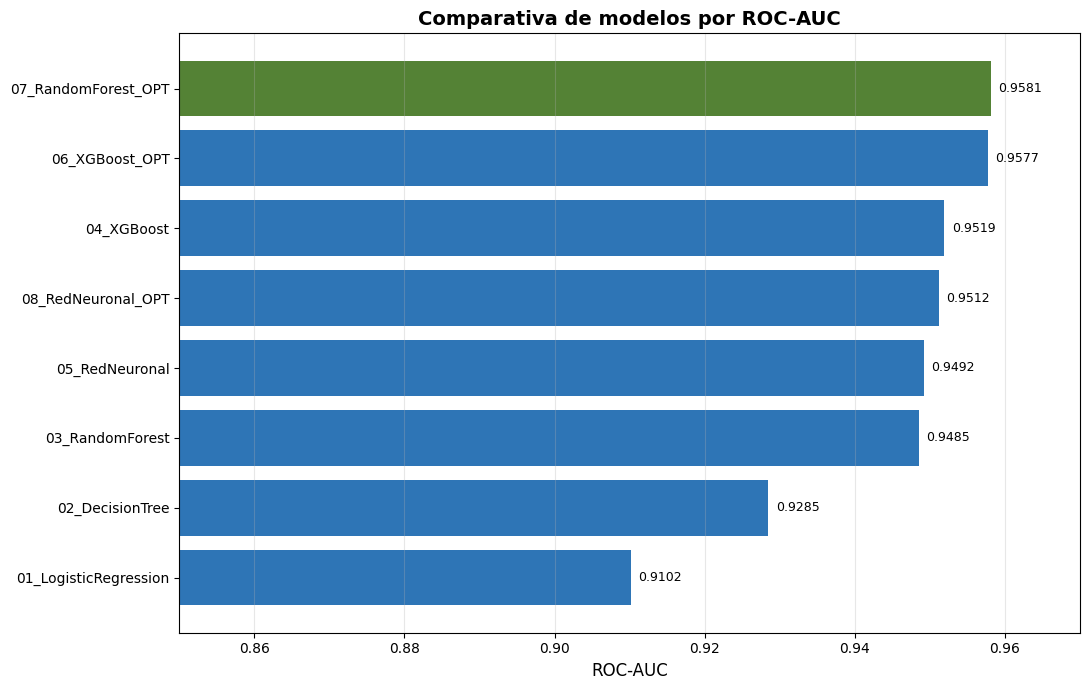

In [7]:
"""Grafico de barras de ROC-AUC (lee de disco, sin reentrenar)."""

metricas = cargar_todas_las_metricas()

evaluation.graficar_barras_roc_auc(metricas)

## 2. Preparación de datos y entrenamiento de modelos

Para las curvas ROC, matrices de confusión y feature importance necesitamos
los modelos entrenados (no solo sus métricas). Cargamos los datos y entrenamos
los modelos clave.

Para mantener el tiempo razonable, entrenamos los modelos base (rápidos) y el
RandomForest, que es nuestro ganador y el que analizaremos en detalle.

In [8]:
"""Cargar datos preprocesados."""

from src.data_loader import preparar_datos

X_train, X_test, y_train, y_test, preprocesador = preparar_datos()

# Nombres de las features (para feature importance)
nombres_features = preprocesador.get_feature_names_out().tolist()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Numero de features: {len(nombres_features)}")

Eliminadas 13 filas con valores imposibles (0.011% del total).
X_train: (95501, 130)
X_test:  (23876, 130)
Numero de features: 130


In [9]:
"""Entrenar modelos para las curvas ROC (sin MLflow para ir rapido)."""

from src.models import (
    entrenar_logistic_regression,
    entrenar_decision_tree,
    entrenar_random_forest,
    entrenar_xgboost,
)

# Entrenamos sin loguear en MLflow (mas rapido) y guardamos las probabilidades
print("Entrenando LogisticRegression...")
modelo_lr, _ = entrenar_logistic_regression(X_train, y_train, X_test, y_test, log_en_mlflow=False)

print("Entrenando DecisionTree...")
modelo_dt, _ = entrenar_decision_tree(X_train, y_train, X_test, y_test, log_en_mlflow=False)

print("Entrenando RandomForest...")
modelo_rf, _ = entrenar_random_forest(X_train, y_train, X_test, y_test, log_en_mlflow=False)

print("Entrenando XGBoost...")
modelo_xgb, _ = entrenar_xgboost(X_train, y_train, X_test, y_test, log_en_mlflow=False)

print("\nModelos entrenados.")

Entrenando LogisticRegression...
Entrenando DecisionTree...
Entrenando RandomForest...
Entrenando XGBoost...

Modelos entrenados.


## 3. Curvas ROC comparativas

La curva ROC representa la tasa de verdaderos positivos frente a la de falsos
positivos para distintos umbrales. Cuanto más cerca de la esquina superior
izquierda, mejor. El área bajo la curva es el ROC-AUC.

Figura guardada: C:\Juan\Pontia\ML\practica-final-ml\practica-final-ml\resultados\figuras\curvas_roc.png


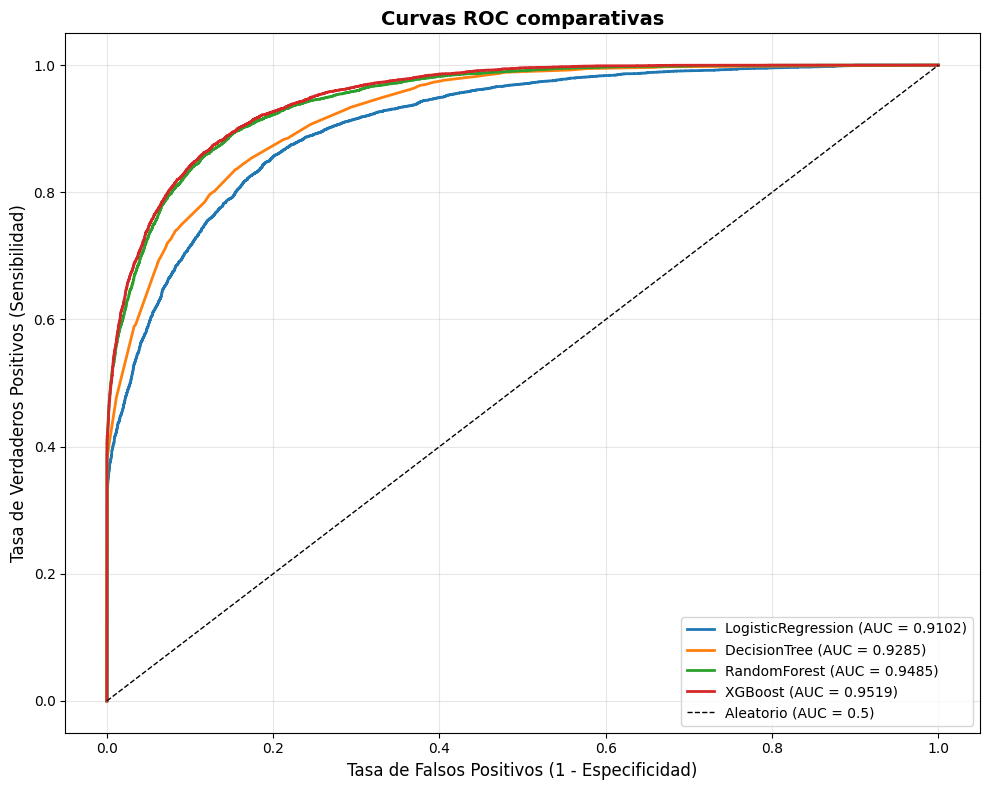

In [10]:
"""Curvas ROC comparativas."""

modelos_probas = {
    "LogisticRegression": modelo_lr.predict_proba(X_test)[:, 1],
    "DecisionTree": modelo_dt.predict_proba(X_test)[:, 1],
    "RandomForest": modelo_rf.predict_proba(X_test)[:, 1],
    "XGBoost": modelo_xgb.predict_proba(X_test)[:, 1],
}

evaluation.graficar_curvas_roc(modelos_probas, y_test)

## 4. Matriz de confusión del modelo ganador

Analizamos el RandomForest, nuestro mejor modelo. La matriz de confusión
muestra los 4 tipos de resultado:

- **Verdaderos negativos**: predijo "no cancela" y acertó.
- **Falsos positivos**: predijo "cancela" pero no canceló.
- **Falsos negativos**: predijo "no cancela" pero sí canceló (el error más
  costoso para un hotel: no se preparó para una cancelación real).
- **Verdaderos positivos**: predijo "cancela" y acertó.

Figura guardada: C:\Juan\Pontia\ML\practica-final-ml\practica-final-ml\resultados\figuras\matriz_confusion_RandomForest.png


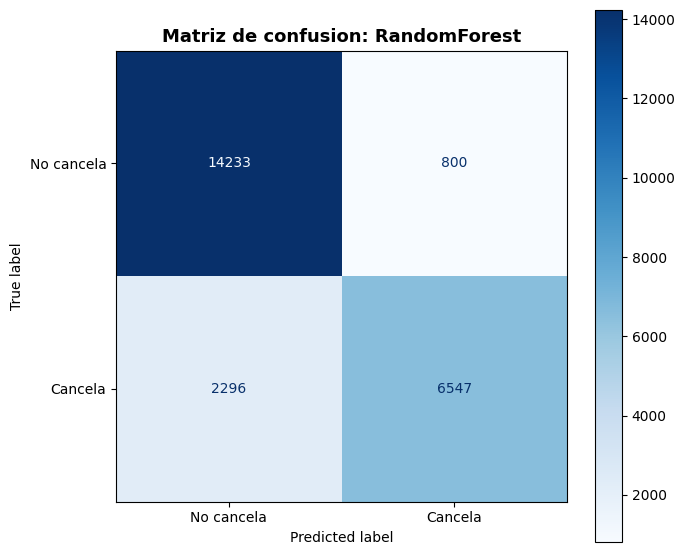

In [11]:
"""Matriz de confusion del RandomForest."""

y_pred_rf = modelo_rf.predict(X_test)

evaluation.graficar_matriz_confusion(y_test, y_pred_rf, nombre_modelo="RandomForest")

## 5. Feature importance del modelo ganador

¿Qué variables impulsan las predicciones? El feature importance nos dice qué
features usa más el modelo para decidir. Esto valida (o refuta) las hipótesis
del EDA: esperábamos que `lead_time`, `deposit_type` y
`total_of_special_requests` fueran predictivas.

Figura guardada: C:\Juan\Pontia\ML\practica-final-ml\practica-final-ml\resultados\figuras\feature_importance_RandomForest.png


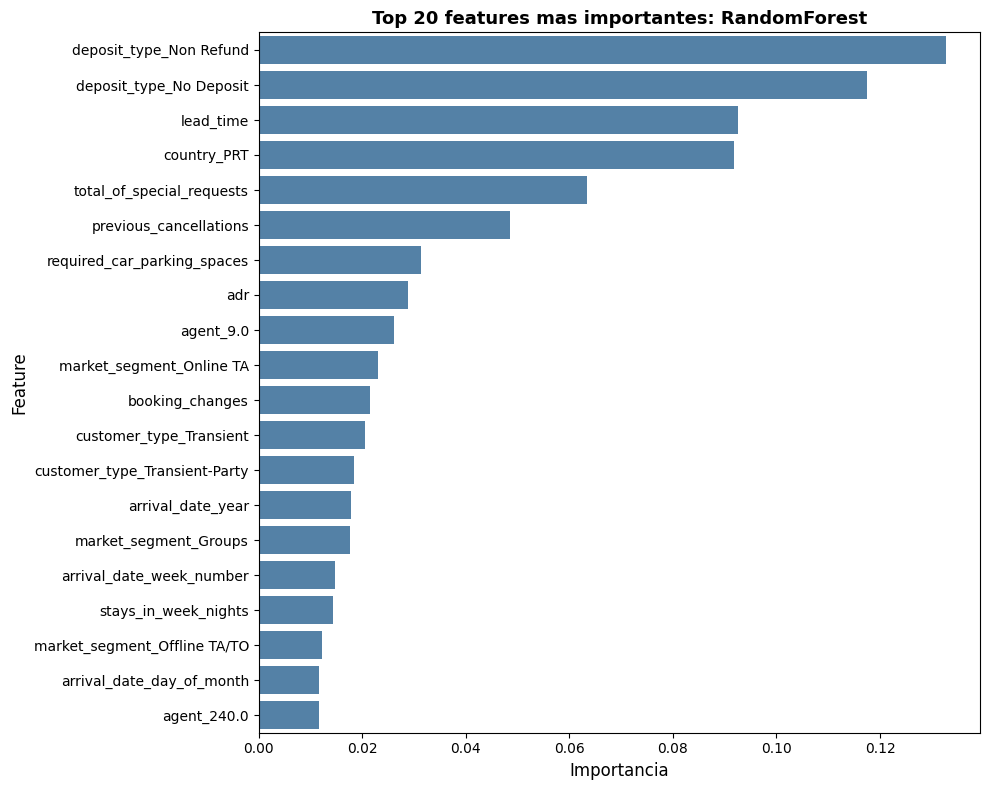


Top 10 features mas importantes:
                    feature  importancia
    deposit_type_Non Refund     0.132674
    deposit_type_No Deposit     0.117447
                  lead_time     0.092477
                country_PRT     0.091808
  total_of_special_requests     0.063348
     previous_cancellations     0.048498
required_car_parking_spaces     0.031327
                        adr     0.028849
                  agent_9.0     0.026184
   market_segment_Online TA     0.022968


In [12]:
"""Feature importance del RandomForest."""

df_importancia = evaluation.graficar_feature_importance(
    modelo_rf,
    nombres_features,
    top_n=20,
    nombre_modelo="RandomForest",
)

print("\nTop 10 features mas importantes:")
print(df_importancia.head(10).to_string(index=False))